# HR Employee Attrition Analysis (Tenure & Career Stagnation Attrition Analysis)

**Tujuan notebook ini:** menjawab business question ke-4: Bagaimana pengaruh tenure & career stagnation terhadap attrition?

## 1. Setup & Load Data

Load data langsung dari MySQL supaya konsisten dengan sumber data yang sudah dinormalisasi.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
from scipy import stats

load_dotenv()

host = os.environ.get("DB_HOST")
user = os.environ.get("DB_USER")
password = os.environ.get("DB_PASSWORD")
database = os.environ.get("DB_NAME")

url_connect = f"mysql+pymysql://{user}:{password}@{host}/{database}"

engine = create_engine(url_connect)

In [2]:
query = """ SELECT
                attrition,
                years_at_company,
                years_since_last_promotion,
                years_with_curr_manager
            FROM employees"""

with engine.connect() as koneksi:
    df = pd.read_sql(query, con=koneksi)

In [3]:
print(f"Jumlah baris & kolom: {df.shape}")
df.head()

Jumlah baris & kolom: (1470, 4)


,attrition,years_at_company,years_since_last_promotion,years_with_curr_manager
0,Yes,6,0,5
1,No,10,1,7
2,Yes,0,0,0
3,No,8,3,0
4,No,2,2,2


### Menambahkan Kolom `rasio_years`

Selain ketiga variabel tenure yang ada di data, akan dibuat 1 variabel turunan `rasio_years` — proporsi masa kerja yang dihabiskan tanpa promosi (`years_since_last_promotion` dibagi `years_at_company`). Variabel ini berpotensi menjadi indikator stagnasi karier yang lebih presisi dibanding angka mentah `years_since_last_promotion` saja, karena memperhitungkan konteks lama bekerja tiap karyawan.

In [4]:
rasio = df['years_since_last_promotion'] / df['years_at_company']
rasio = rasio.fillna(0)
df['rasio_years'] = rasio
df['rasio_years'].head()

0    0.000
1    0.100
2    0.000
3    0.375
4    1.000
Name: rasio_years, dtype: float64

Rasio mendekati 1 berarti karyawan itu tidak pernah dipromosikan sejak masuk kerja (stagnan). Sementara itu, rasio mendekati 0 itu berarti baru saja dipromosikan relatif terhadap masa kerjanya. Lebih lanjut, untuk yang baru masuk (`years_at_company` == 0) diset rasio-nya menjadi 0.

## 2. Analisis Deskriptif

Lakukan analisis deskriptif sederhana untuk mengetahui hubungan tenure & career stagnation terhadap attrition.

In [5]:
tenure_attrition_rate = df.groupby('attrition').agg(['mean', 'median'])
tenure_attrition_rate = tenure_attrition_rate.round(2)
tenure_attrition_rate

years_at_company        years_since_last_promotion         \
                      mean median                       mean median   
attrition                                                             
No                    7.37    6.0                       2.23    1.0   
Yes                   5.13    3.0                       1.95    1.0   

          years_with_curr_manager        rasio_years         
                             mean median        mean median  
attrition                                                    
No                           4.37    3.0        0.29   0.17  
Yes                          2.85    2.0        0.31   0.14

Karyawan yang keluar memiliki median `years_at_company` yang lebih rendah (3 tahun) dibanding yang bertahan (6 tahun), serta median `years_with_curr_manager` yang juga lebih rendah. Sementara `years_since_last_promotion` terlihat mirip di kedua kelompok (median sama-sama 1 tahun). Sebelum menguji signifikansi masing-masing variabel, perlu dicek dulu apakah ketiganya saling berkorelasi tinggi satu sama lain.

### Heatmap Korelasi

#### Cek multikolinearitas antar 3 variabel asli

Sebelum masuk ke uji statistik, perlu dicek dulu apakah ketiga variabel tenure ini (`years_at_company`, `years_since_last_promotion`, `years_with_curr_manager`) saling berkorelasi tinggi satu sama lain.

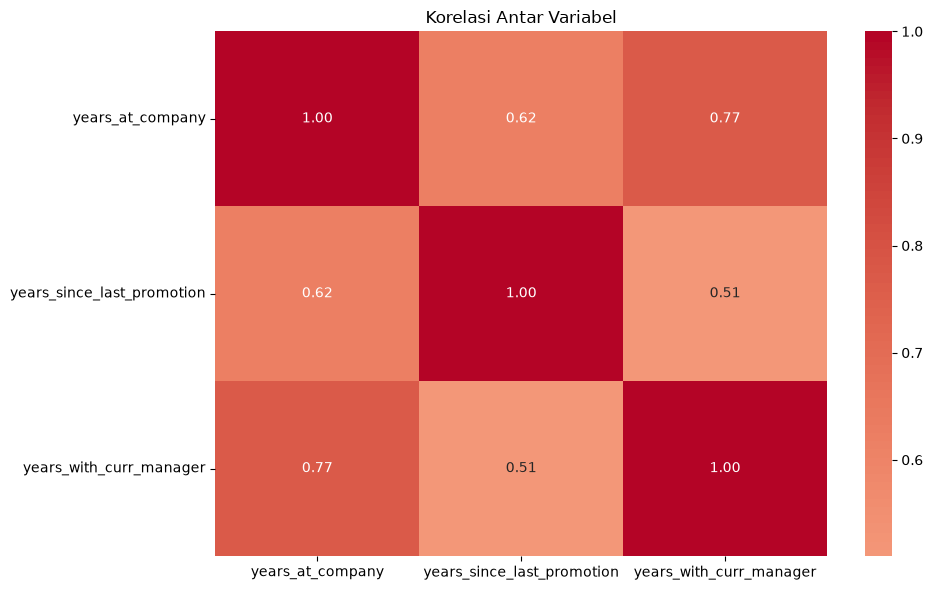

In [6]:
plt.figure(figsize=(10, 6))
corr = df[['years_at_company', 'years_since_last_promotion', 'years_with_curr_manager']].corr()
sns.heatmap(corr, annot = True, cmap = 'coolwarm', center = 0, fmt ='.2f')
plt.title('Korelasi Antar Variabel')
plt.yticks(rotation = 0)
plt.tight_layout()
plt.show()

Ketiga variabel menunjukkan korelasi yang cukup tinggi satu sama lain, terutama antara `years_at_company` dan `years_with_curr_manager` (0,77) — masuk akal karena karyawan yang lebih lama bekerja di perusahaan secara alami juga cenderung lebih lama dengan manajer yang sama.

#### Cek apakah `rasio_years` redundan

Selain ketiga variabel asli, sebelumnya sudah dibuat variabel turunan `rasio_years` (proporsi masa kerja yang dihabiskan tanpa promosi) sebagai indikator stagnasi karier yang lebih presisi dibanding angka mentah `years_since_last_promotion` saja. Namun, sebelum variabel ini dianggap layak diuji secara terpisah, perlu dipastikan dulu apakah dia benar-benar membawa informasi baru, atau justru sekadar duplikat (redundan) dari salah satu variabel tenure yang sudah ada. Dengan demikian, heatmap korelasi diperluas dengan menyertakan `rasio_years`.

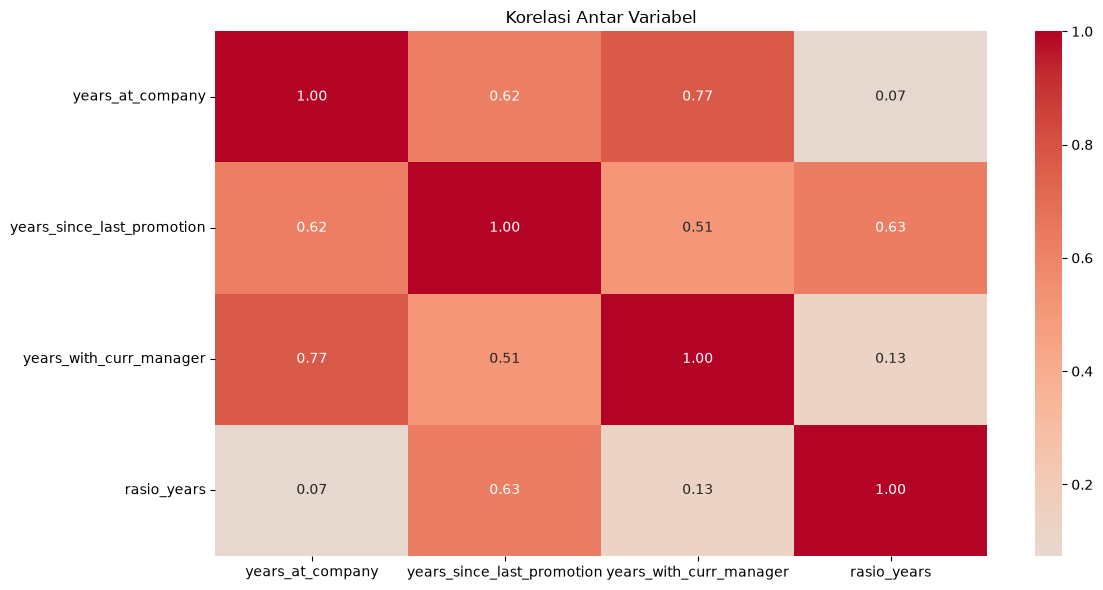

In [7]:
plt.figure(figsize=(12, 6))
corr = df.drop('attrition', axis=1).corr()
sns.heatmap(corr, annot = True, cmap = 'coolwarm', center = 0, fmt ='.2f')
plt.title('Korelasi Antar Variabel')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

Korelasi `rasio_years` terhadap ketiga variabel asli tergolong rendah — dengan `years_at_company` (0,07) dan `years_with_curr_manager` (0,13), meski agak lebih tinggi dengan `years_since_last_promotion` (0,63) yang memang menjadi komponen pembentuknya. Karena korelasinya tidak cukup tinggi untuk dianggap sepenuhnya redundan, `rasio_years` tetap layak dimasukkan sebagai variabel keempat dalam uji statistik nanti, untuk melihat apakah proporsi stagnasi karier ini punya asosiasi tersendiri dengan attrition yang tidak tertangkap oleh ketiga variabel aslinya.

### Pengelompokan Data Berdasarkan Attrition

Selanjutnya, bagi data untuk dikelompokkan berdasarkan attrition, sebagai persiapan untuk uji distribusi, deteksi outlier, dan uji statistik di tahap berikutnya.

In [8]:
attrition_yes = df.loc[
    df['attrition'] == 'Yes', 
    ['years_at_company', 'years_since_last_promotion', 'years_with_curr_manager', 'rasio_years']
]

attrition_no = df.loc[
    df['attrition'] == 'No',
    ['years_at_company', 'years_since_last_promotion', 'years_with_curr_manager', 'rasio_years']
]

### Distribusi Data & Skewness

Lakukan visualisasi sederhana untuk melihat distribusi data & skewness-nya berdasarkan kelompok attrition_yes dan attrition_no, sekaligus mengecek apakah data cukup normal untuk menentukan uji statistik yang tepat.

Skewness kelompok attrition_yes kolom years_at_company: 2.67
Skewness kelompok attrition_no kolom years_at_company: 1.66
Skewness kelompok attrition_yes kolom years_since_last_promotion: 2.2
Skewness kelompok attrition_no kolom years_since_last_promotion: 1.94
Skewness kelompok attrition_yes kolom years_with_curr_manager: 1.02
Skewness kelompok attrition_no kolom years_with_curr_manager: 0.8
Skewness kelompok attrition_yes kolom rasio_years: 0.79
Skewness kelompok attrition_no kolom rasio_years: 0.99


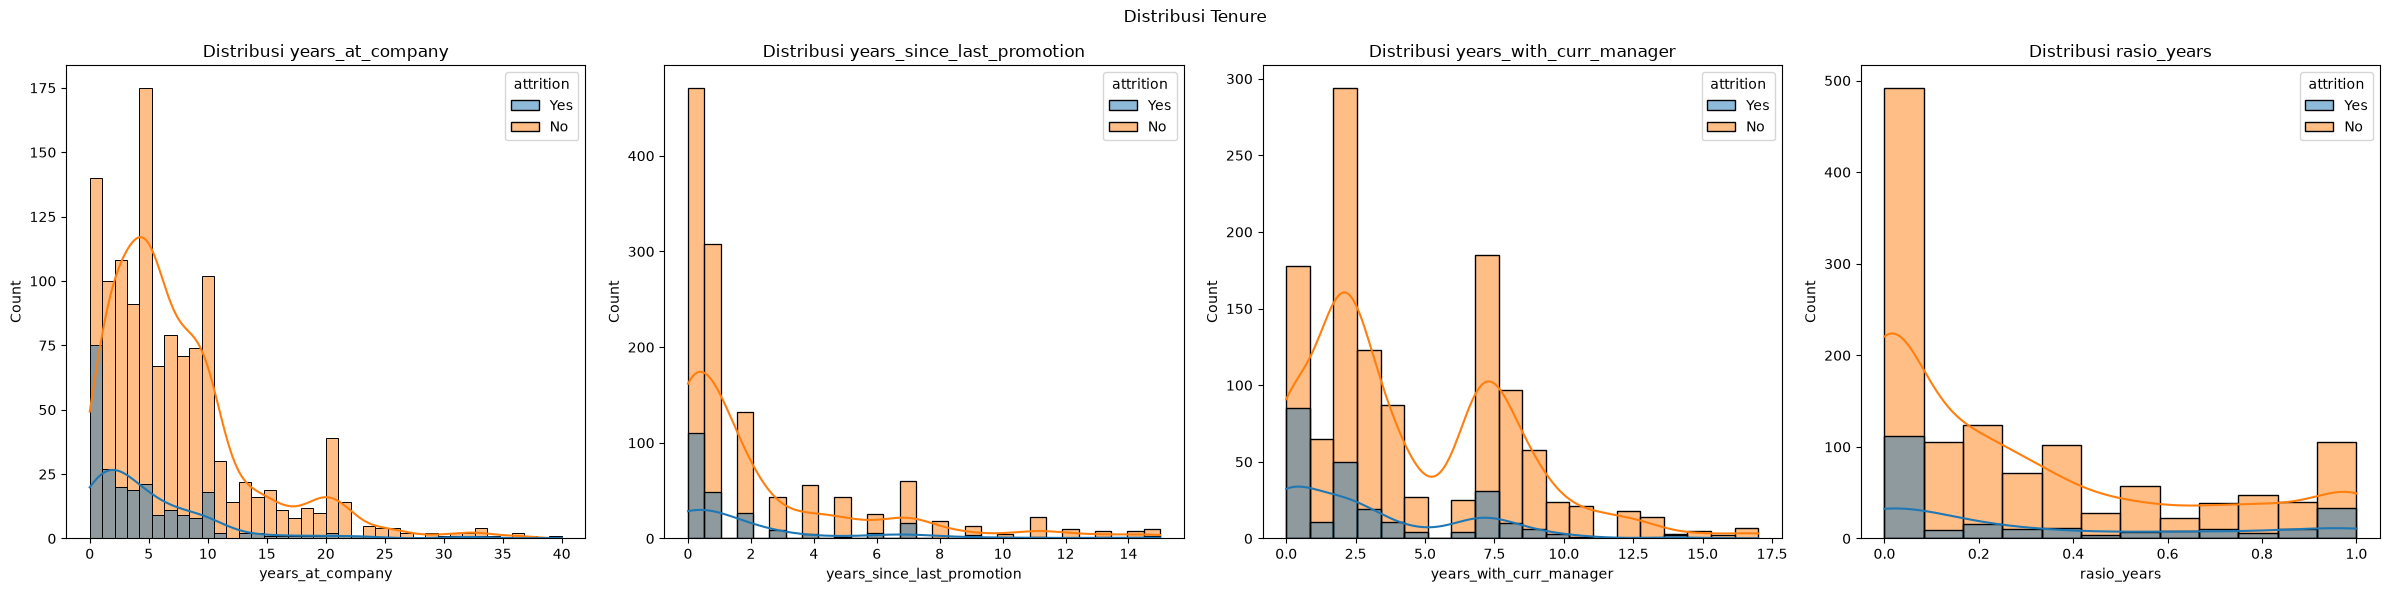

In [9]:
from scipy.stats import skew

n = len(df.drop('attrition', axis=1).columns)
fig, axes = plt.subplots(1, n, figsize=(6*n, 6))

for ax, column in zip(axes, df.drop('attrition', axis=1).columns):
    print(f"Skewness kelompok attrition_yes kolom {column}: {skew(attrition_yes[column]).round(2)}")
    print(f"Skewness kelompok attrition_no kolom {column}: {skew(attrition_no[column]).round(2)}")
    sns.histplot(df, x=df[column], hue='attrition', ax=ax, kde=True)
    ax.set_title(f"Distribusi {column}")

plt.suptitle("Distribusi Tenure")
plt.tight_layout()
plt.show()

Seluruh kolom menunjukkan nilai skewness **positif** (>0) di kedua kelompok, dengan `years_at_company` paling menjulur ke kanan (skewness 2,67 pada attrition_yes, 1,66 pada attrition_no). Ini mengindikasikan data tidak berdistribusi normal, sehingga uji non-parametrik (Mann-Whitney U) tetap menjadi pilihan yang tepat untuk keempat variabel, termasuk `rasio_years`.

### Outlier

Membuat fungsi outliers untuk mengetahui jumlah outlier di tiap kolom pada masing-masing kelompok, menggunakan metode **IQR** dengan Q1/Q3 dihitung dari keseluruhan data (global) — bukan dari masing-masing subset — supaya kedua kelompok dibandingkan dengan standar ambang batas yang sama.

In [10]:
def outliers(df1):
    for column in df1.columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
    
        batas_bawah = Q1 - IQR * 1.5
        batas_atas = Q3 + IQR * 1.5

        outlier = df1.loc[
            (df1[column] < batas_bawah) | (df1[column] > batas_atas), 
            column]
        print(f"Jumlah outlier di kolom {column} adalah {len(outlier)}")

### Outlier Kelompok Attrition Yes

In [11]:
outliers(attrition_yes)

Jumlah outlier di kolom years_at_company adalah 10
Jumlah outlier di kolom years_since_last_promotion adalah 13
Jumlah outlier di kolom years_with_curr_manager adalah 0
Jumlah outlier di kolom rasio_years adalah 0


Dalam kelompok attrition_yes, terdapat 10 outlier di kolom `years_at_company` dan 13 outlier di kolom `years_since_last_promotion`. Sementara itu, kolom `years_with_curr_manager` dan `rasio_years` tidak memiliki outlier sama sekali.

### Outlier Kelompok Attrition No

In [12]:
outliers(attrition_no)

Jumlah outlier di kolom years_at_company adalah 94
Jumlah outlier di kolom years_since_last_promotion adalah 94
Jumlah outlier di kolom years_with_curr_manager adalah 14
Jumlah outlier di kolom rasio_years adalah 0


Dalam kelompok attrition_no, terdapat 94 outlier di kolom `years_at_company` dan kolom `years_since_last_promotion`, serta 14 outlier di kolom `years_with_curr_manager`. Sementara itu, kolom `rasio_years` tidak memiliki outlier sama sekali.

Terdapat total **104 outlier** di kolom `years_at_company` *(10 di kelompok attrition_yes, 94  di kelompok attrition_no)*, **107 outlier** di kolom `years_since_last_promotion` *(13 di kelompok attrition_yes, 94 di kelompok attrition_no)*, dan **14 outlier** di kolom `years_with_curr_manager`*(semuanya di kelompok attrition_no)*. Secara proporsi terhadap ukuran masing-masing kelompok, penyebaran outlier lebih di kelompok attrition_no lebih banyak dibandingkan dengan penyebaran outlier di kelompok attrition_yes. Sementara itu, kolom `rasio_years` **tidak memiliki outlier** sama sekali.

## 3. Uji Statistik & Effect Size

Menguji tingkat asosiasi antara 2 kelompok kategorikal (attrition Yes/No) terhadap masing-masing variabel tenure (`years_at_company`, `years_since_last_promotion`, `years_with_curr_manager`) dan variabel turunan `rasio_years`, menggunakan **Mann-Whitney U test** dan **rank-biserial correlation** sebagai effect size.

In [13]:
def mann_whitney(df1, df2):
    mwu, p_value = stats.mannwhitneyu(df1, df2)
    hasil_mwu = f"Nilai statistik Mann-Whitney U test: {mwu}"
    if p_value < 0.0001:
        hasil_p_value = "P-value < 0.0001"
    else:
        hasil_p_value = f"P-value: {p_value:.4f}"
    return mwu, hasil_mwu, hasil_p_value

In [14]:
def rank_biserial(mwu, df1, df2):
    N1 = len(df1)
    N2 = len(df2)
    r_bs = 1 - (2 * mwu) / (N1 * N2)
    print(f"Nilai Rank-Biserial nya: {r_bs:.4f}")

### Terhadap `years_at_company`

In [15]:
mwu1, hasil_mwu1, p_value1 = mann_whitney(attrition_yes['years_at_company'], attrition_no['years_at_company'])
print(hasil_mwu1)
print(p_value1)

Nilai statistik Mann-Whitney U test: 102582.0
P-value < 0.0001


Nilai p-value kurang dari 0,0001 menunjukkan terdapat asosiasi yang **signifikan secara statistik** antara 2 kelompok attrition (Yes/No) terhadap kolom `years_at_company`. Selanjutnya, menggunakan **rank-biserial correlation** untuk mengetahui seberapa kuat hubungannya.

In [16]:
rank_biserial(mwu1, attrition_yes, attrition_no)

Nilai Rank-Biserial nya: 0.2979


Diperoleh nilai rank-biserial correlation-nya sebesar **0,2979** — mendekati namun belum mencapai ambang moderate (0,30) — menunjukkan kekuatan asosiasi **antara lemah hingga sedang**.

### Terhadap `years_since_last_promotion`

In [17]:
mwu2, hasil_mwu2, p_value2 = mann_whitney(attrition_yes['years_since_last_promotion'], attrition_no['years_since_last_promotion'])
print(hasil_mwu2)
print(p_value2)

Nilai statistik Mann-Whitney U test: 134374.0
P-value: 0.0412


Nilai p-value sebesar 0,0412 — sedikit di bawah ambang 0,05 — menunjukkan asosiasi yang **signifikan secara statistik** antara 2 kelompok attrition (Yes/No) terhadap kolom `years_since_last_promotion`. Selanjutnya, menggunakan **rank-biserial correlation** untuk mengetahui seberapa kuat hubungannya.

In [18]:
rank_biserial(mwu2, attrition_yes, attrition_no)

Nilai Rank-Biserial nya: 0.0803


Diperoleh nilai rank-biserial correlation-nya sebesar **0,0803** — jauh di bawah kategori lemah (0,10) — menunjukkan kekuatan asosiasi yang **sangat lemah**.

### Terhadap `years_with_curr_manager`

In [19]:
mwu3, hasil_mwu3, p_value3 = mann_whitney(attrition_yes['years_with_curr_manager'], attrition_no['years_with_curr_manager'])
print(hasil_mwu3)
print(p_value3)

Nilai statistik Mann-Whitney U test: 106361.5
P-value < 0.0001


Nilai p-value kurang dari 0,0001 menunjukkan terdapat asosiasi yang **signifikan secara statistik** antara 2 kelompok attrition (Yes/No) terhadap kolom `years_with_curr_manager`. Selanjutnya, menggunakan **rank-biserial correlation** untuk mengetahui seberapa kuat hubungannya.

In [20]:
rank_biserial(mwu3,  attrition_yes, attrition_no)

Nilai Rank-Biserial nya: 0.2720


Diperoleh nilai rank-biserial correlation-nya sebesar **0,2720** — sebanding dengan `years_at_company` — menunjukkan kekuatan asosiasi **antara lemah hingga sedang**.

### Terhadap `rasio_years`

In [21]:
mwu4, hasil_mwu4, p_value4 = mann_whitney(attrition_yes['rasio_years'], attrition_no['rasio_years'])
print(hasil_mwu4)
print(p_value4)

Nilai statistik Mann-Whitney U test: 144768.0
P-value: 0.8168


Nilai p-value sebesar 0,8168 — lebih dari 0,05 — menunjukkan **tidak terdapat asosiasi yang signifikan secara statistik** antara 2 kelompok attrition (Yes/No) terhadap kolom `rasio_years`. Selanjutnya, menggunakan **rank-biserial correlation** untuk mengetahui seberapa kuat hubungannya.

In [22]:
rank_biserial(mwu4, attrition_yes, attrition_no)

Nilai Rank-Biserial nya: 0.0092


Diperoleh nilai rank-biserial correlation-nya sebesar **0,0092** — nyaris nol — menunjukkan kekuatan asosiasi yang **sangat lemah**. Ini juga mengonfirmasi bahwa proporsi stagnasi karier ini tidak terbukti membedakan karyawan yang keluar dengan yang bertahan, meskipun sebelumnya sudah terkonfirmasi tidak redundan secara korelasi dengan ketiga variabel tenure asli.

## 4. Visualisasi

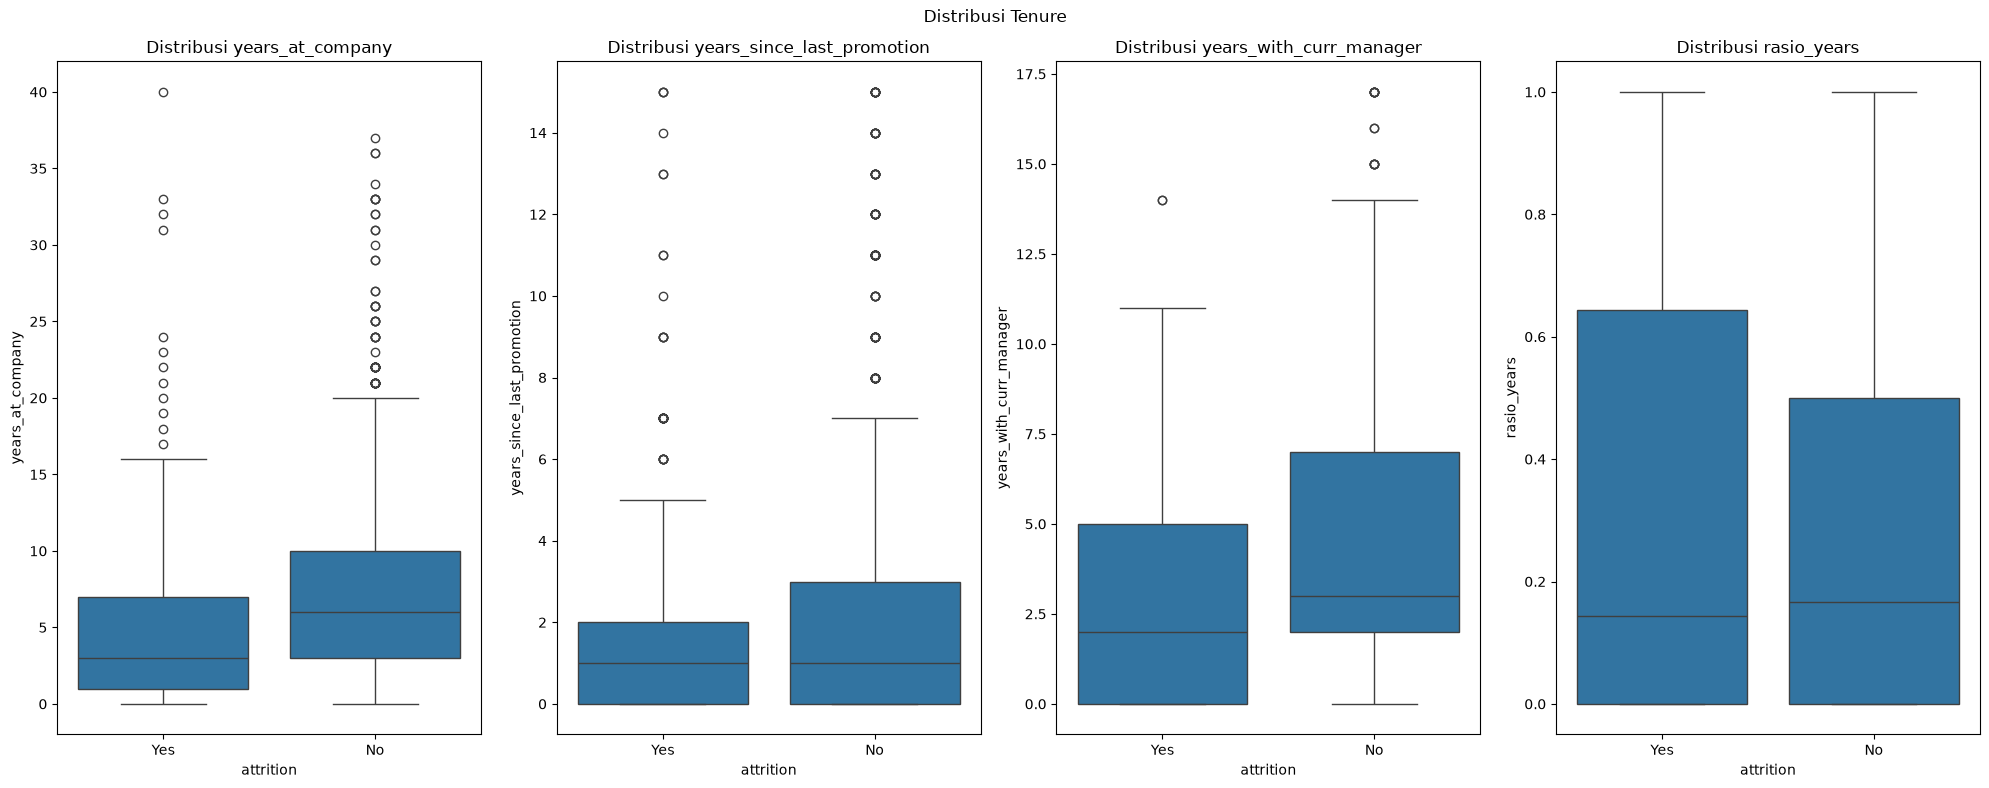

In [23]:
n = len(df.drop('attrition', axis=1).columns)
fig, axes = plt.subplots(1, n, figsize=(5*n, 8))

for ax, column in zip(axes, df.drop('attrition', axis=1).columns):
    sns.boxplot(data=df, x='attrition', y=column, ax=ax)
    ax.set_title(f"Distribusi {column}")

plt.suptitle("Distribusi Tenure")
plt.tight_layout()
plt.show()

**Notes:** sama seperti pada analisis kompensasi (Q3), titik-titik di boxplot ini adalah outlier *relatif terhadap grup masing-masing* (bawaan `sns.boxplot`), berbeda dari analisis outlier di section 2 yang menggunakan ambang batas global.

## Kesimpulan

Dari ketiga variabel tenure yang diuji dengan Mann-Whitney U test, dua di antaranya menunjukkan asosiasi yang meyakinkan secara statistik, satu menunjukkan asosiasi yang sangat lemah, dan variabel turunan `rasio_years` tidak menunjukkan asosiasi sama sekali.

**Years at Company** menunjukkan perbedaan signifikan (U = 102.582,0; p < 0,0001). Karyawan yang keluar memiliki median masa kerja yang lebih pendek (3 tahun) dibanding yang bertahan (6 tahun). Rank-biserial correlation sebesar 0,2979 menunjukkan asosiasi antara lemah hingga sedang.

**Years with Current Manager** juga signifikan (U = 106.361,5; p < 0,0001), dengan pola serupa. Rank-biserial correlation sebesar 0,2720 sebanding dengan years_at_company.

**Years Since Last Promotion** signifikan secara statistik namun tipis (U = 134.374,0; p = 0,0412), dengan effect size yang sangat kecil (0,0803, di bawah kategori lemah Cohen). Dengan ukuran sampel besar (1.470 karyawan), hasil ini kemungkinan mencerminkan perbedaan yang secara praktis kecil, bukan efek yang benar-benar berarti.

**Rasio Years** tidak menunjukkan asosiasi signifikan (p = 0,8168; rank-biserial = 0,0092), meskipun terbukti tidak redundan secara korelasi dengan ketiga variabel asli.

**Catatan multikolinearitas**: heatmap korelasi menunjukkan `years_at_company` berkorelasi tinggi dengan `years_with_curr_manager` (0,77) dan sedang dengan `years_since_last_promotion` (0,62), sementara `years_since_last_promotion` dan `years_with_curr_manager` berkorelasi sedang (0,51). Ini wajar karena karyawan yang lebih lama bekerja di perusahaan cenderung juga lebih lama dengan manajer yang sama — sehingga efek yang teramati pada `years_at_company` dan `years_with_curr_manager` kemungkinan sebagian saling menjelaskan. Sementara itu, `rasio_years` berkorelasi rendah dengan `years_at_company` (0,07) dan `years_with_curr_manager` (0,13), namun cukup tinggi dengan `years_since_last_promotion` (0,63) yang memang menjadi komponen pembentuknya.

**Catatan batasan**: seperti pada Q2 dan Q3, hasil ini menunjukkan asosiasi, bukan hubungan sebab-akibat, karena sifat data yang cross-sectional.

**Implikasi praktis**: dari keempat variabel yang diuji, **years_at_company** dan **years_with_curr_manager** adalah dua faktor tenure yang paling layak menjadi perhatian HR — periode awal bekerja (baik dengan perusahaan maupun dengan manajer barunya) tampak menjadi masa paling rentan terhadap keputusan keluar. Sementara durasi sejak promosi terakhir dan rasio stagnasi karier tidak terbukti menjadi faktor pembeda yang kuat pada dataset ini.